In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
dados_path = Path("dados")

arquivos = [
    "1container_100users.csv",
    "1container_400users.csv",
    "1container_800users.csv",
    "2containers_100users.csv",
    "2containers_400users.csv",
    "2containers_800users.csv",
    "3containers_100users.csv",
    "3containers_400users.csv",
    "3containers_800users.csv"
]

In [4]:
registros = []

for arquivo in arquivos:
    df = pd.read_csv(dados_path / arquivo)
    agregado = df[df["Name"] == "Aggregated"].iloc[0]

    partes = arquivo.replace(".csv", "").split("_")
    containers = int(partes[0].replace("containers", "").replace("container", ""))
    usuarios = int(partes[1].replace("users", ""))

    registros.append({
        "containers": containers,
        "usuarios": usuarios,
        "tempo_medio_resposta": agregado["Average Response Time"],
        "mediana_resposta": agregado["Median Response Time"],
        "rps": agregado["Requests/s"],
        "falhas": agregado["Failure Count"],
        "requisicoes": agregado["Request Count"]
    })

resultado = pd.DataFrame(registros)
resultado

,containers,usuarios,tempo_medio_resposta,mediana_resposta,rps,falhas,requisicoes
0,1,100,94.427387,84.0,46.192708,0,4395
1,1,400,224.936956,180.0,176.591302,0,13800
2,1,800,1431.753096,1500.0,225.869717,2956,25685
3,2,100,99.852280,85.0,46.260231,0,5578
4,2,400,196.973971,110.0,180.643643,0,22686
5,2,800,415.375705,170.0,317.138078,13068,29716
6,3,100,95.295512,81.0,45.623668,0,4712
7,3,400,199.139670,110.0,180.059094,0,21346
8,3,800,478.832784,210.0,314.259268,19677,53883


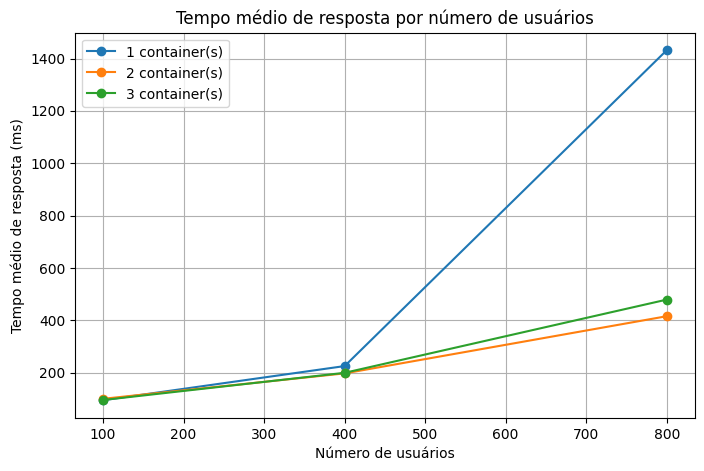

In [5]:
plt.figure(figsize=(8, 5))

for containers in sorted(resultado["containers"].unique()):
    dados = resultado[resultado["containers"] == containers].sort_values("usuarios")
    plt.plot(dados["usuarios"], dados["tempo_medio_resposta"], marker="o", label=f"{containers} container(s)")

plt.xlabel("Número de usuários")
plt.ylabel("Tempo médio de resposta (ms)")
plt.title("Tempo médio de resposta por número de usuários")
plt.legend()
plt.grid(True)
plt.show()

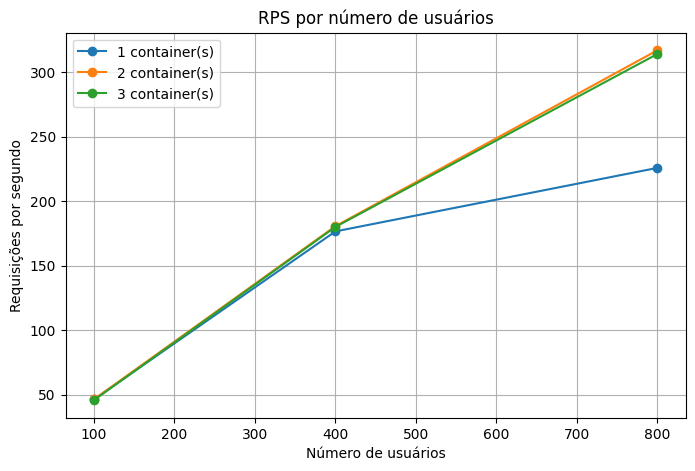

In [6]:
plt.figure(figsize=(8, 5))

for containers in sorted(resultado["containers"].unique()):
    dados = resultado[resultado["containers"] == containers].sort_values("usuarios")
    plt.plot(dados["usuarios"], dados["rps"], marker="o", label=f"{containers} container(s)")

plt.xlabel("Número de usuários")
plt.ylabel("Requisições por segundo")
plt.title("RPS por número de usuários")
plt.legend()
plt.grid(True)
plt.show()

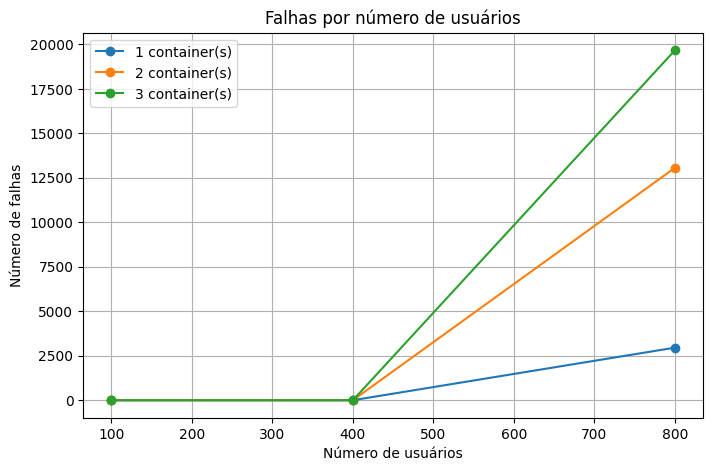

In [7]:
plt.figure(figsize=(8, 5))

for containers in sorted(resultado["containers"].unique()):
    dados = resultado[resultado["containers"] == containers].sort_values("usuarios")
    plt.plot(dados["usuarios"], dados["falhas"], marker="o", label=f"{containers} container(s)")

plt.xlabel("Número de usuários")
plt.ylabel("Número de falhas")
plt.title("Falhas por número de usuários")
plt.legend()
plt.grid(True)
plt.show()

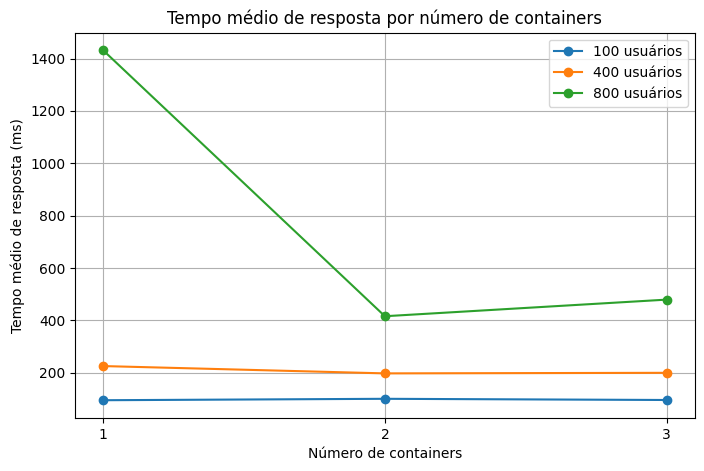

In [8]:
plt.figure(figsize=(8, 5))

for usuarios in sorted(resultado["usuarios"].unique()):
    dados = resultado[resultado["usuarios"] == usuarios].sort_values("containers")
    plt.plot(dados["containers"], dados["tempo_medio_resposta"], marker="o", label=f"{usuarios} usuários")

plt.xlabel("Número de containers")
plt.ylabel("Tempo médio de resposta (ms)")
plt.title("Tempo médio de resposta por número de containers")
plt.xticks([1, 2, 3])
plt.legend()
plt.grid(True)
plt.show()

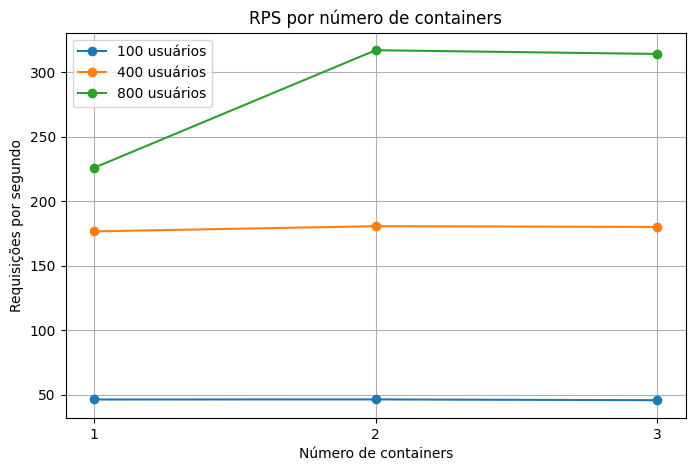

In [9]:
plt.figure(figsize=(8, 5))

for usuarios in sorted(resultado["usuarios"].unique()):
    dados = resultado[resultado["usuarios"] == usuarios].sort_values("containers")
    plt.plot(dados["containers"], dados["rps"], marker="o", label=f"{usuarios} usuários")

plt.xlabel("Número de containers")
plt.ylabel("Requisições por segundo")
plt.title("RPS por número de containers")
plt.xticks([1, 2, 3])
plt.legend()
plt.grid(True)
plt.show()

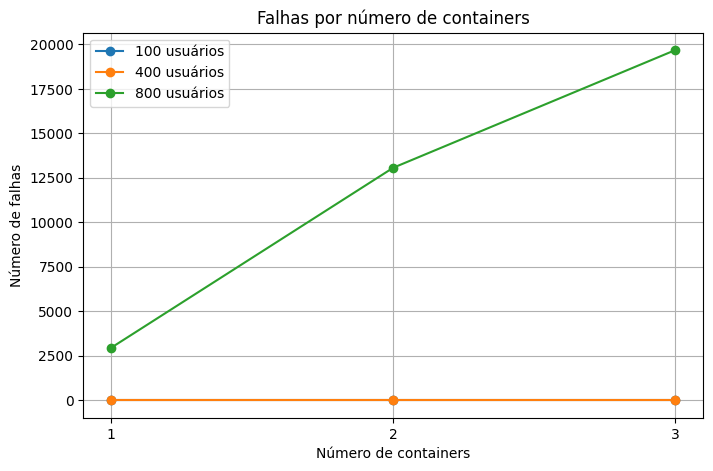

In [10]:
plt.figure(figsize=(8, 5))

for usuarios in sorted(resultado["usuarios"].unique()):
    dados = resultado[resultado["usuarios"] == usuarios].sort_values("containers")
    plt.plot(dados["containers"], dados["falhas"], marker="o", label=f"{usuarios} usuários")

plt.xlabel("Número de containers")
plt.ylabel("Número de falhas")
plt.title("Falhas por número de containers")
plt.xticks([1, 2, 3])
plt.legend()
plt.grid(True)
plt.show()

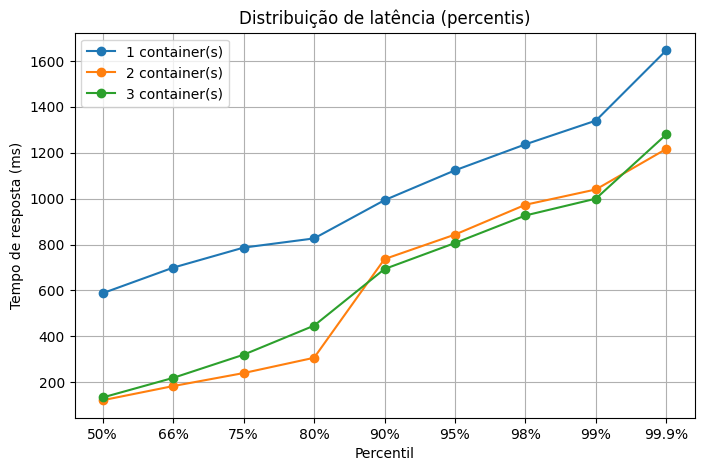

In [11]:
percentis = ["50%", "66%", "75%", "80%", "90%", "95%", "98%", "99%", "99.9%"]

plt.figure(figsize=(8, 5))

for containers in sorted(resultado["containers"].unique()):
    df_plot = []
    
    for usuarios in [100, 400, 800]:
        df = pd.read_csv(dados_path / f"{containers}container{'s' if containers > 1 else ''}_{usuarios}users.csv")
        agg = df[df["Name"] == "Aggregated"].iloc[0]
        valores = [agg[p] for p in percentis]
        df_plot.append(valores)
    
    media = pd.DataFrame(df_plot).mean()
    plt.plot(percentis, media, marker="o", label=f"{containers} container(s)")

plt.xlabel("Percentil")
plt.ylabel("Tempo de resposta (ms)")
plt.title("Distribuição de latência (percentis)")
plt.legend()
plt.grid(True)
plt.show()

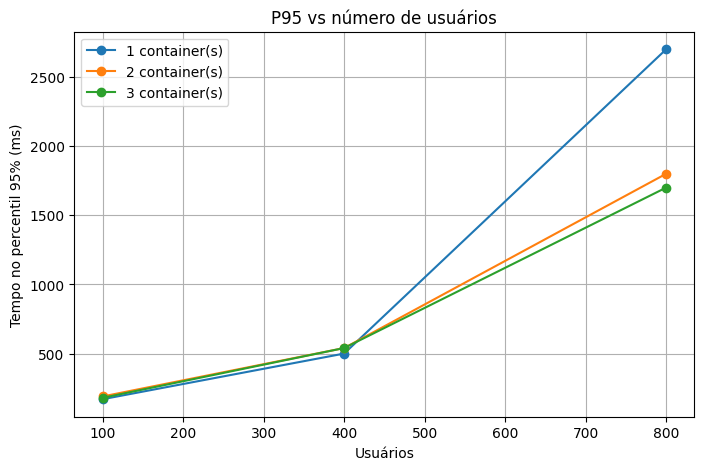

In [12]:
plt.figure(figsize=(8, 5))

for containers in sorted(resultado["containers"].unique()):
    dados = []
    
    for usuarios in [100, 400, 800]:
        df = pd.read_csv(dados_path / f"{containers}container{'s' if containers > 1 else ''}_{usuarios}users.csv")
        agg = df[df["Name"] == "Aggregated"].iloc[0]
        dados.append(agg["95%"])
    
    plt.plot([100, 400, 800], dados, marker="o", label=f"{containers} container(s)")

plt.xlabel("Usuários")
plt.ylabel("Tempo no percentil 95% (ms)")
plt.title("P95 vs número de usuários")
plt.legend()
plt.grid(True)
plt.show()

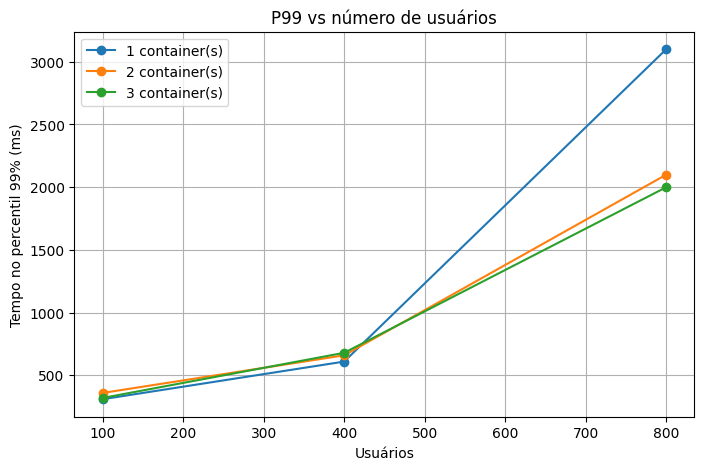

In [13]:
plt.figure(figsize=(8, 5))

for containers in sorted(resultado["containers"].unique()):
    dados = []
    
    for usuarios in [100, 400, 800]:
        df = pd.read_csv(dados_path / f"{containers}container{'s' if containers > 1 else ''}_{usuarios}users.csv")
        agg = df[df["Name"] == "Aggregated"].iloc[0]
        dados.append(agg["99%"])
    
    plt.plot([100, 400, 800], dados, marker="o", label=f"{containers} container(s)")

plt.xlabel("Usuários")
plt.ylabel("Tempo no percentil 99% (ms)")
plt.title("P99 vs número de usuários")
plt.legend()
plt.grid(True)
plt.show()

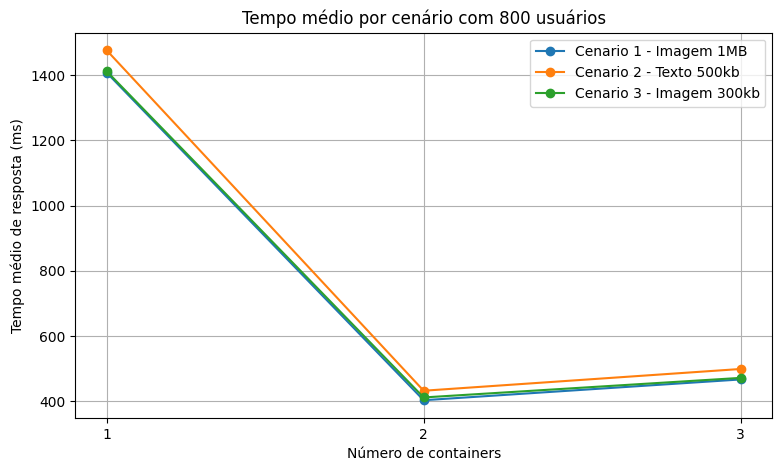

In [14]:
cenarios = [
    "Cenario 1 - Imagem 1MB",
    "Cenario 2 - Texto 500kb",
    "Cenario 3 - Imagem 300kb"
]

plt.figure(figsize=(9, 5))

for cenario in cenarios:
    dados_cenario = []

    for arquivo in arquivos:
        df = pd.read_csv(dados_path / arquivo)
        linha = df[df["Name"] == cenario].iloc[0]

        partes = arquivo.replace(".csv", "").split("_")
        containers = int(partes[0].replace("containers", "").replace("container", ""))
        usuarios = int(partes[1].replace("users", ""))

        dados_cenario.append({
            "containers": containers,
            "usuarios": usuarios,
            "tempo_medio_resposta": linha["Average Response Time"]
        })

    df_cenario = pd.DataFrame(dados_cenario)
    df_800 = df_cenario[df_cenario["usuarios"] == 800].sort_values("containers")

    plt.plot(df_800["containers"], df_800["tempo_medio_resposta"], marker="o", label=cenario)

plt.xlabel("Número de containers")
plt.ylabel("Tempo médio de resposta (ms)")
plt.title("Tempo médio por cenário com 800 usuários")
plt.xticks([1, 2, 3])
plt.legend()
plt.grid(True)
plt.show()

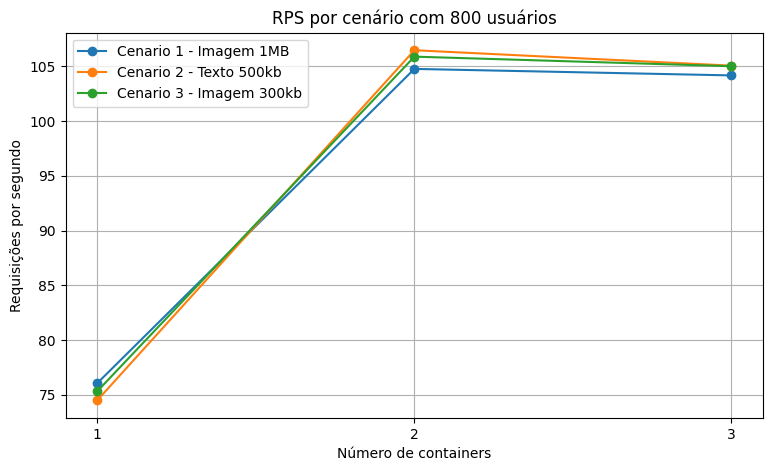

In [15]:
plt.figure(figsize=(9, 5))

for cenario in cenarios:
    dados_cenario = []

    for arquivo in arquivos:
        df = pd.read_csv(dados_path / arquivo)
        linha = df[df["Name"] == cenario].iloc[0]

        partes = arquivo.replace(".csv", "").split("_")
        containers = int(partes[0].replace("containers", "").replace("container", ""))
        usuarios = int(partes[1].replace("users", ""))

        dados_cenario.append({
            "containers": containers,
            "usuarios": usuarios,
            "rps": linha["Requests/s"]
        })

    df_cenario = pd.DataFrame(dados_cenario)
    df_800 = df_cenario[df_cenario["usuarios"] == 800].sort_values("containers")

    plt.plot(df_800["containers"], df_800["rps"], marker="o", label=cenario)

plt.xlabel("Número de containers")
plt.ylabel("Requisições por segundo")
plt.title("RPS por cenário com 800 usuários")
plt.xticks([1, 2, 3])
plt.legend()
plt.grid(True)
plt.show()